# 2. Summary Statistic Sensitivity Analysis

Which summary stats are informative about which model parameters?
Which stats track learning across sessions? Which are redundant?

**Part A**: Single-session param-stat correlations — sample params from prior,
simulate, compute stats, correlate.

**Part B**: Multi-session trajectory sensitivity — generate synthetic animals
with known eta trajectories, compute stats per session, correlate with
session index and true eta.

In [1]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
from scipy.stats import spearmanr
import warnings, time
warnings.filterwarnings('ignore')

from Models.BE_core import BEParams, BEState, BEModel
from Analysis.summary_stats import (
    compute_summary_stats, list_available_stats,
    get_stat_names_expanded, flatten_stats,
)
from Data.structures import (
    generate_synthetic_animal, sample_stimuli, stimulus_to_category,
    param_trajectory_naive_to_expert,
)

PARAM_NAMES = ['sigma_percep', 'A_repulsion', 'eta_learning', 'eta_relax']

# Stats to evaluate (everything except update_matrix)
CANDIDATE_STATS = [
    'accuracy', 'psychometric', 'recency', 'win_stay', 'lose_shift',
    'stimulus_sensitivity', 'side_bias', 'choice_autocorr', 'choice_entropy',
    'perseveration', 'hard_easy_ratio', 'hard_accuracy', 'easy_accuracy',
    'logistic_history',
    'binned_accuracy', 'binned_choice_prob',
]

print("Available stats:", list_available_stats())
print(f"Evaluating {len(CANDIDATE_STATS)} stat groups")

Available stats: ['accuracy', 'psychometric', 'recency', 'win_stay', 'win_stay_rate', 'lose_shift', 'choice_autocorr', 'side_bias', 'stimulus_sensitivity', 'choice_entropy', 'perseveration', 'logistic_history', 'hard_easy_ratio', 'hard_accuracy', 'easy_accuracy', 'update_matrix', 'binned_accuracy', 'binned_choice_prob']
Evaluating 16 stat groups


## Part A: Single-Session Param-Stat Correlations

For each simulation: sample params from uniform prior over bounds,
simulate 300 trials, compute all candidate stats. Then compute
Spearman correlations between each param and each stat.

In [2]:
# --- Configuration ---
N_SAMPLES = 3000   # Number of simulations (increase for smoother results)
N_TRIALS = 300
BURN_IN = 100
SEED = 42

In [3]:
# --- Run simulations ---
rng = np.random.default_rng(SEED)
bounds = BEParams.get_bounds()
expanded_names = get_stat_names_expanded(CANDIDATE_STATS)
n_stats = len(expanded_names)

param_values = np.empty((N_SAMPLES, 4))
stat_values = np.empty((N_SAMPLES, n_stats))

print(f"Simulating {N_SAMPLES} sessions with {n_stats} stats each...")
t0 = time.time()
n_failed = 0

for i in range(N_SAMPLES):
    if i % 500 == 0 and i > 0:
        elapsed = time.time() - t0
        rate = i / elapsed
        print(f"  {i}/{N_SAMPLES} ({elapsed:.0f}s, ~{(N_SAMPLES-i)/rate:.0f}s left)")
    
    # Sample params uniformly from bounds
    params = BEParams(
        sigma_percep=rng.uniform(*bounds['sigma_percep']),
        A_repulsion=rng.uniform(*bounds['A_repulsion']),
        eta_learning=rng.uniform(*bounds['eta_learning']),
        eta_relax=rng.uniform(*bounds['eta_relax']),
    )
    param_values[i] = params.to_array()
    
    # Simulate with burn-in
    state = BEState.initial_uniform()
    burn_stim = rng.uniform(-1.0, 1.0, BURN_IN)
    burn_cats = stimulus_to_category(burn_stim)
    _, _, state, _ = BEModel.simulate_session(params, state, burn_stim, burn_cats, rng)
    
    stimuli = sample_stimuli(N_TRIALS, 'Uniform', rng)
    categories = stimulus_to_category(stimuli)
    choices, _, _, _ = BEModel.simulate_session(params, state, stimuli, categories, rng)
    
    try:
        stats = compute_summary_stats(
            choices, stimuli, categories,
            stat_names=CANDIDATE_STATS, return_dict=False,
        )
        if len(stats) == n_stats:
            stat_values[i] = stats
        else:
            stat_values[i] = np.nan
            n_failed += 1
    except Exception:
        stat_values[i] = np.nan
        n_failed += 1

elapsed = time.time() - t0
valid_mask = ~np.any(np.isnan(stat_values), axis=1)
param_values_clean = param_values[valid_mask]
stat_values_clean = stat_values[valid_mask]
print(f"Done in {elapsed:.1f}s. {valid_mask.sum()}/{N_SAMPLES} valid ({n_failed} failures)")

Simulating 3000 sessions with 40 stats each...
  500/3000 (9s, ~47s left)
  1000/3000 (19s, ~38s left)
  1500/3000 (28s, ~28s left)
  2000/3000 (37s, ~18s left)
  2500/3000 (46s, ~9s left)
Done in 55.0s. 3000/3000 valid (0 failures)


In [4]:
# --- Compute Spearman correlations: params vs stats ---
param_stat_corr = np.empty((4, n_stats))
param_stat_pval = np.empty((4, n_stats))

for p in range(4):
    for s in range(n_stats):
        sv = stat_values_clean[:, s]
        vm = ~np.isnan(sv)
        if vm.sum() < 30:
            param_stat_corr[p, s] = np.nan
            param_stat_pval[p, s] = np.nan
        else:
            rho, pval = spearmanr(param_values_clean[vm, p], sv[vm])
            param_stat_corr[p, s] = rho
            param_stat_pval[p, s] = pval

# Inter-stat correlations
stat_stat_corr = np.empty((n_stats, n_stats))
for i in range(n_stats):
    for j in range(n_stats):
        vi, vj = stat_values_clean[:, i], stat_values_clean[:, j]
        vm = ~np.isnan(vi) & ~np.isnan(vj)
        if vm.sum() < 30:
            stat_stat_corr[i, j] = np.nan
        else:
            rho, _ = spearmanr(vi[vm], vj[vm])
            stat_stat_corr[i, j] = rho

print("Correlations computed.")

Correlations computed.


### Param-Stat Correlation Heatmap

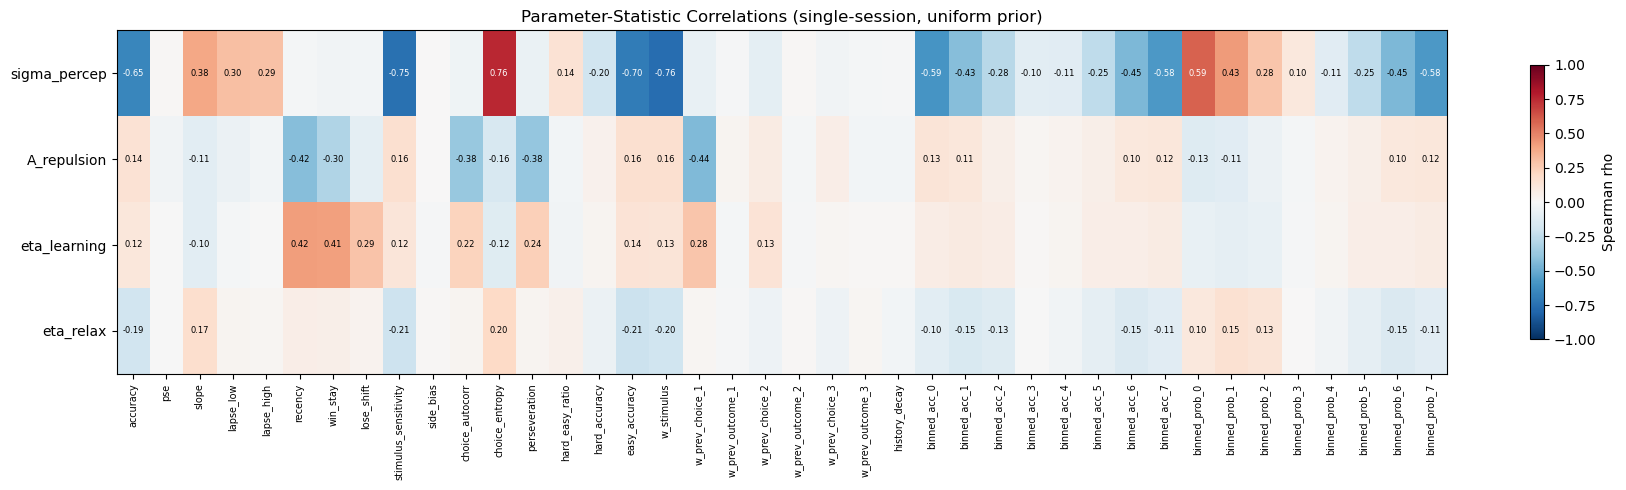

In [5]:
fig, ax = plt.subplots(figsize=(max(14, n_stats * 0.45), 5))

im = ax.imshow(param_stat_corr, aspect='auto', cmap='RdBu_r', vmin=-1, vmax=1)
ax.set_yticks(range(4))
ax.set_yticklabels(PARAM_NAMES)
ax.set_xticks(range(n_stats))
ax.set_xticklabels(expanded_names, rotation=90, fontsize=7)

for i in range(4):
    for j in range(n_stats):
        val = param_stat_corr[i, j]
        if not np.isnan(val) and abs(val) > 0.1:
            color = 'white' if abs(val) > 0.5 else 'black'
            ax.text(j, i, f'{val:.2f}', ha='center', va='center', fontsize=6, color=color)

plt.colorbar(im, ax=ax, shrink=0.8, label='Spearman rho')
ax.set_title('Parameter-Statistic Correlations (single-session, uniform prior)')
plt.tight_layout()
plt.show()

### Inter-Stat Redundancy Heatmap

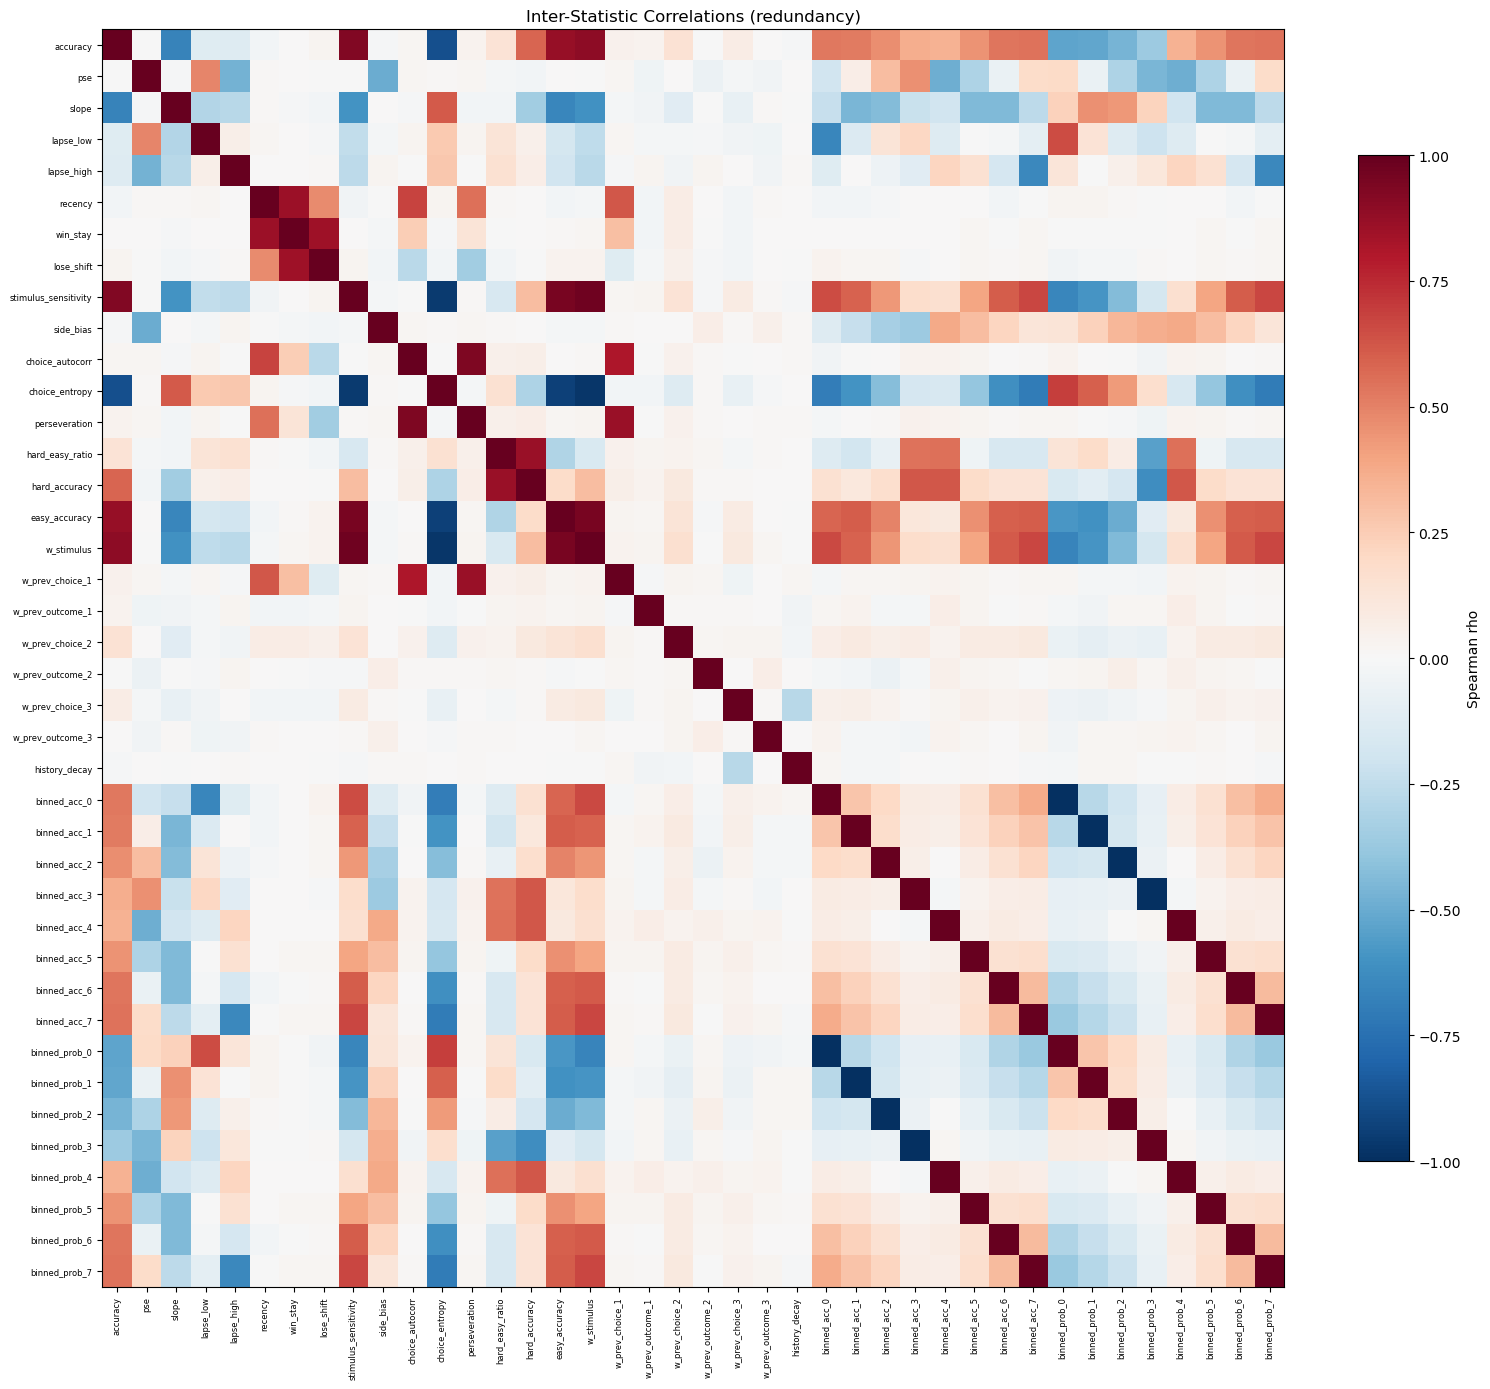

In [6]:
fig, ax = plt.subplots(figsize=(max(12, n_stats * 0.4), max(10, n_stats * 0.35)))

im = ax.imshow(stat_stat_corr, aspect='auto', cmap='RdBu_r', vmin=-1, vmax=1)
ax.set_xticks(range(n_stats))
ax.set_xticklabels(expanded_names, rotation=90, fontsize=6)
ax.set_yticks(range(n_stats))
ax.set_yticklabels(expanded_names, fontsize=6)
plt.colorbar(im, ax=ax, shrink=0.8, label='Spearman rho')
ax.set_title('Inter-Statistic Correlations (redundancy)')
plt.tight_layout()
plt.show()

### Per-Parameter Discriminability

For each parameter: which stats have strong correlation with that parameter
but weak correlation with others? Stars mark uniquely informative stats.

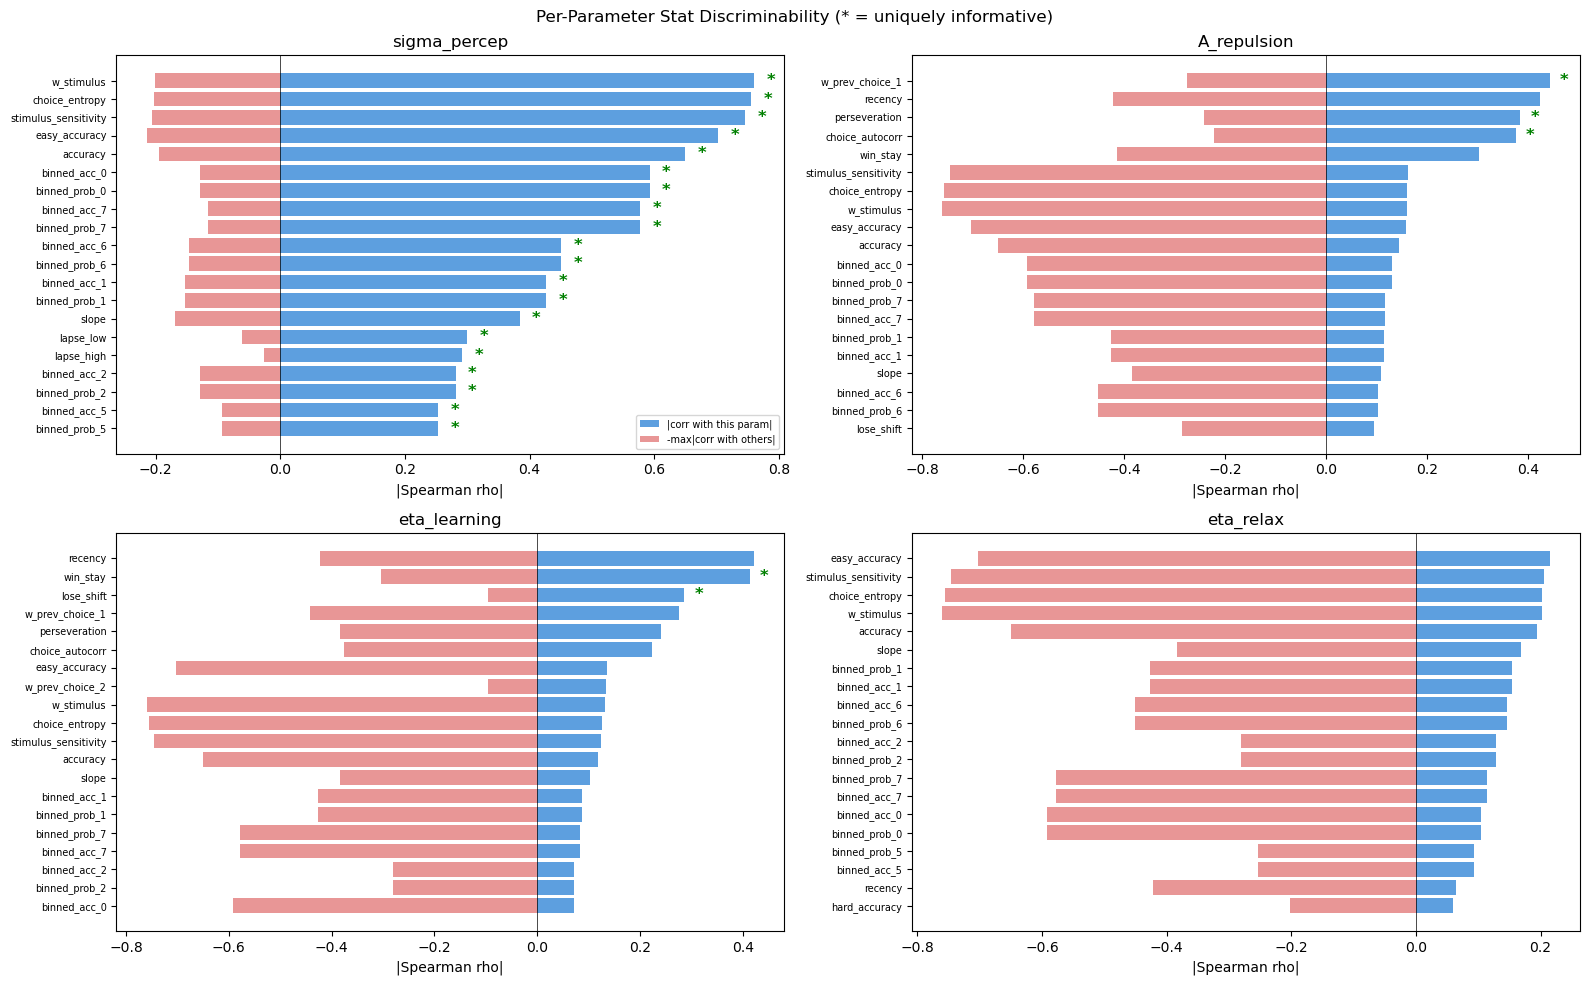

In [7]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

for p, (ax, pname) in enumerate(zip(axes.flat, PARAM_NAMES)):
    abs_this = np.abs(param_stat_corr[p, :])
    other_mask = np.ones(4, dtype=bool)
    other_mask[p] = False
    abs_others = np.max(np.abs(param_stat_corr[other_mask, :]), axis=0)
    uniqueness = abs_this - abs_others
    
    order = np.argsort(abs_this)[::-1][:20]
    names = [expanded_names[i] for i in order]
    y = np.arange(len(order))
    
    ax.barh(y, abs_this[order], color='#1976d2', alpha=0.7, label='|corr with this param|')
    ax.barh(y, -abs_others[order], color='#d32f2f', alpha=0.5, label='-max|corr with others|')
    
    for i, idx in enumerate(order):
        if uniqueness[idx] > 0.05 and abs_this[idx] > 0.15:
            ax.text(abs_this[idx] + 0.02, i, '*', fontsize=12, fontweight='bold',
                   color='green', va='center')
    
    ax.set_yticks(y)
    ax.set_yticklabels(names, fontsize=7)
    ax.set_xlabel('|Spearman rho|')
    ax.set_title(pname)
    ax.axvline(0, color='k', linewidth=0.5)
    ax.invert_yaxis()
    if p == 0:
        ax.legend(fontsize=7)

fig.suptitle('Per-Parameter Stat Discriminability (* = uniquely informative)', fontsize=12)
plt.tight_layout()
plt.show()

## Part B: Multi-Session Trajectory Sensitivity

Generate synthetic animals with declining eta trajectories. For each
session, compute stats. Ask: which stats track learning (session index)
and which correlate directly with true eta?

In [8]:
# --- Configuration ---
N_ANIMALS = 12
N_SESSIONS_TRAJ = 25
N_TRIALS_TRAJ = 300
SEED_B = 123

In [9]:
# --- Generate animals and compute per-session stats ---
rng_master = np.random.default_rng(SEED_B)

all_stats = []
all_sess_idx = []
all_eta = []
per_animal_corrs = np.empty((N_ANIMALS, n_stats))

print(f"Generating {N_ANIMALS} animals ({N_SESSIONS_TRAJ} sessions each)...")
t0 = time.time()

for a in range(N_ANIMALS):
    if a % 4 == 0:
        print(f"  Animal {a}/{N_ANIMALS}")
    
    animal_seed = int(rng_master.integers(0, 2**31))
    
    # Vary trajectory across animals
    eta_start = rng_master.uniform(0.35, 0.55)
    eta_end = rng_master.uniform(0.06, 0.12)
    decay_rate = rng_master.uniform(0.08, 0.20)
    sigma_percep = rng_master.uniform(0.10, 0.22)
    A_repulsion = rng_master.uniform(0.05, 0.20)
    
    params = param_trajectory_naive_to_expert(
        N_SESSIONS_TRAJ, eta_start=eta_start, eta_end=eta_end,
        decay_rate=decay_rate, sigma_percep=sigma_percep, A_repulsion=A_repulsion,
    )
    
    animal, gt = generate_synthetic_animal(
        animal_id=f'SYN_{a:02d}', true_params=params,
        trials_per_session=N_TRIALS_TRAJ, seed=animal_seed,
    )
    
    eta_traj = gt['params_per_session']['eta_learning']
    animal_stats = np.empty((N_SESSIONS_TRAJ, n_stats))
    
    for s_idx, session in enumerate(animal.sessions):
        arrays = session.trials.get_model_arrays(exclude_abort=True, exclude_opto=True)
        try:
            stats = compute_summary_stats(
                arrays['choices'], arrays['stimuli'], arrays['categories'],
                stat_names=CANDIDATE_STATS, return_dict=False,
            )
            animal_stats[s_idx] = stats if len(stats) == n_stats else np.nan
        except Exception:
            animal_stats[s_idx] = np.nan
        
        all_stats.append(animal_stats[s_idx])
        all_sess_idx.append(s_idx)
        all_eta.append(eta_traj[s_idx])
    
    # Per-animal: stat vs session_idx correlation
    sess_arr = np.arange(N_SESSIONS_TRAJ, dtype=float)
    for s in range(n_stats):
        sv = animal_stats[:, s]
        vm = ~np.isnan(sv)
        if vm.sum() >= 5:
            rho, _ = spearmanr(sess_arr[vm], sv[vm])
            per_animal_corrs[a, s] = rho
        else:
            per_animal_corrs[a, s] = np.nan

all_stats = np.array(all_stats)
all_eta = np.array(all_eta)
all_sess_idx = np.array(all_sess_idx)

# Stat-eta direct correlation (pooled)
stat_eta_corr = np.empty(n_stats)
for s in range(n_stats):
    sv = all_stats[:, s]
    vm = ~np.isnan(sv)
    if vm.sum() >= 30:
        rho, _ = spearmanr(all_eta[vm], sv[vm])
        stat_eta_corr[s] = rho
    else:
        stat_eta_corr[s] = np.nan

median_sess_corr = np.nanmedian(per_animal_corrs, axis=0)
print(f"Done in {time.time()-t0:.1f}s")

Generating 12 animals (25 sessions each)...
  Animal 0/12
  Animal 4/12
  Animal 8/12
Done in 4.7s


### Which stats track learning across sessions?

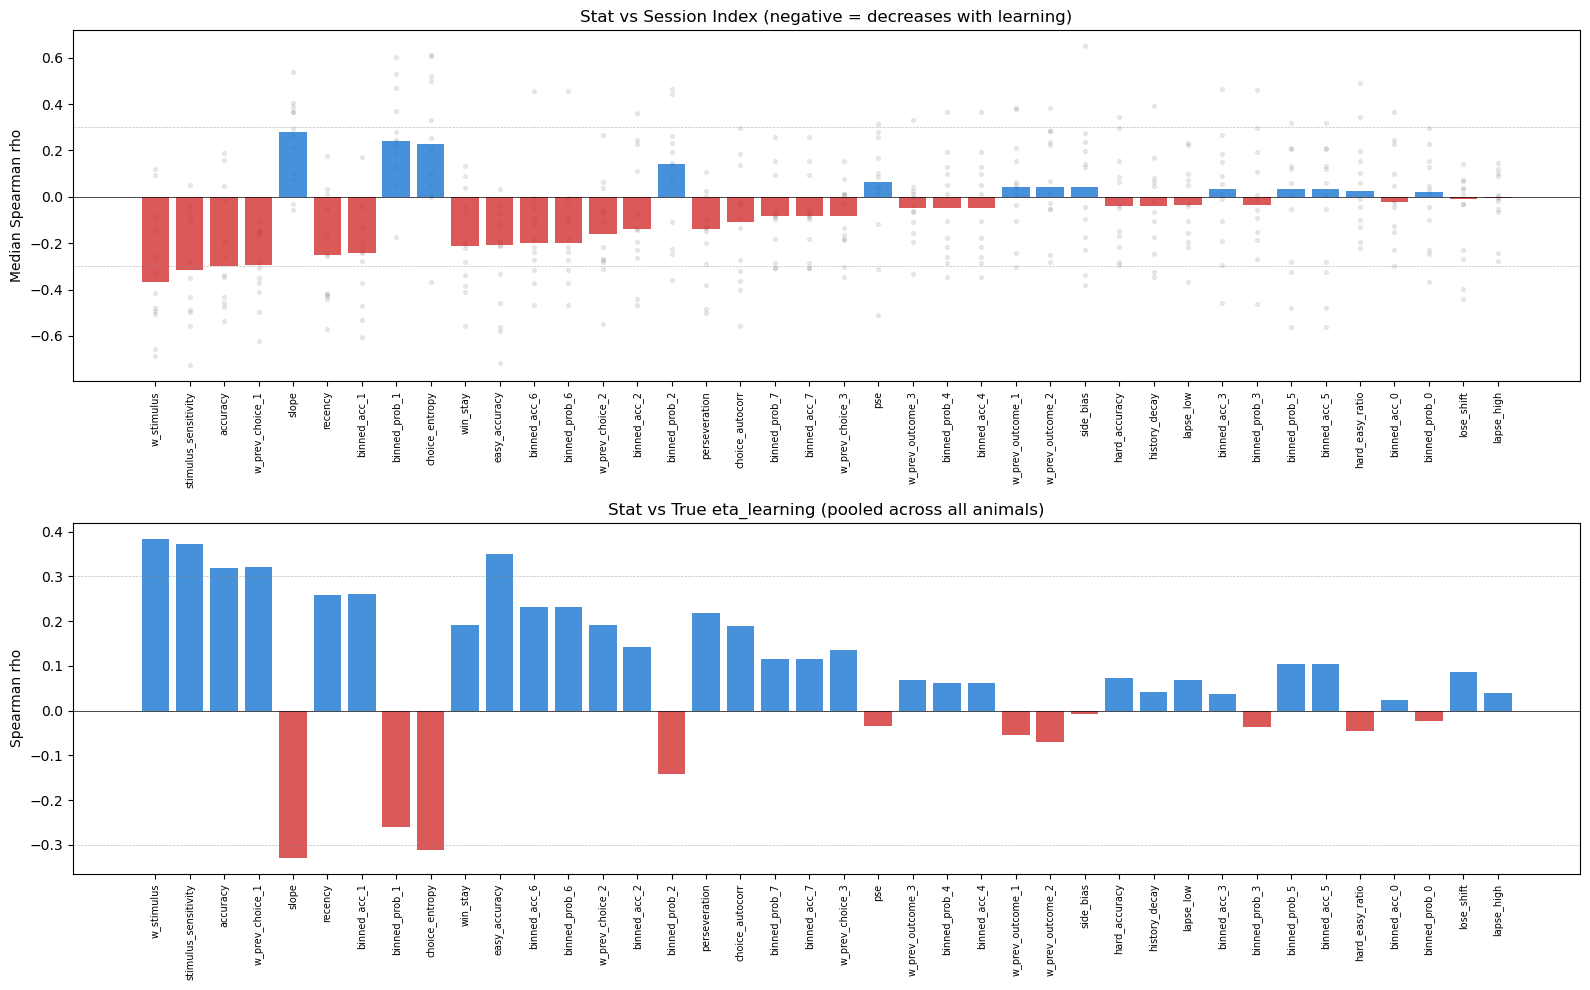

In [10]:
# --- Bar plots: stat vs session_idx, stat vs eta ---
order = np.argsort(np.abs(median_sess_corr))[::-1]

fig, axes = plt.subplots(2, 1, figsize=(max(14, n_stats * 0.4), 10))

# Top: stat vs session index
ax = axes[0]
names_sorted = [expanded_names[i] for i in order]
vals = median_sess_corr[order]

for a in range(N_ANIMALS):
    ax.scatter(range(len(order)), per_animal_corrs[a, order],
               alpha=0.15, s=8, c='grey', zorder=1)

colors = ['#d32f2f' if v < 0 else '#1976d2' for v in vals]
ax.bar(range(len(vals)), vals, color=colors, alpha=0.8, zorder=2)
ax.set_xticks(range(len(names_sorted)))
ax.set_xticklabels(names_sorted, rotation=90, fontsize=7)
ax.set_ylabel('Median Spearman rho')
ax.set_title('Stat vs Session Index (negative = decreases with learning)')
ax.axhline(0, color='k', linewidth=0.5)
ax.axhline(0.3, color='grey', linewidth=0.5, linestyle='--', alpha=0.5)
ax.axhline(-0.3, color='grey', linewidth=0.5, linestyle='--', alpha=0.5)

# Bottom: stat vs true eta
ax = axes[1]
vals_eta = stat_eta_corr[order]
colors_eta = ['#d32f2f' if v < 0 else '#1976d2' for v in vals_eta]
ax.bar(range(len(vals_eta)), vals_eta, color=colors_eta, alpha=0.8)
ax.set_xticks(range(len(names_sorted)))
ax.set_xticklabels(names_sorted, rotation=90, fontsize=7)
ax.set_ylabel('Spearman rho')
ax.set_title('Stat vs True eta_learning (pooled across all animals)')
ax.axhline(0, color='k', linewidth=0.5)
ax.axhline(0.3, color='grey', linewidth=0.5, linestyle='--', alpha=0.5)
ax.axhline(-0.3, color='grey', linewidth=0.5, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

### Combined Summary Table

In [11]:
# --- Summary table ---
print("=" * 110)
print("STAT USEFULNESS RANKING (sorted by |eta_learning correlation|)")
print("=" * 110)
print(f"{'Stat':<22s} {'Best param':<14s} {'rho':<7s} {'eta_corr':<9s} "
      f"{'sess_rho':<9s} {'eta_dir':<8s} {'redundancy':<10s}")
print("-" * 110)

rows = []
for s in range(n_stats):
    max_param_corr = np.nanmax(np.abs(param_stat_corr[:, s]))
    best_p = np.nanargmax(np.abs(param_stat_corr[:, s]))
    eta_corr = param_stat_corr[2, s]  # eta_learning = index 2
    inter = np.nanmean(np.abs(stat_stat_corr[s, :]))
    
    rows.append((
        expanded_names[s], PARAM_NAMES[best_p], param_stat_corr[best_p, s],
        eta_corr, median_sess_corr[s], stat_eta_corr[s], inter
    ))

rows.sort(key=lambda r: abs(r[5]) if not np.isnan(r[5]) else 0, reverse=True)

for name, bp, bp_rho, ec, sc, ed, inter in rows:
    flag = ''
    if abs(ed) > 0.3:
        flag = '<-- GOOD for eta'
    elif abs(bp_rho) > 0.3 and abs(ec) < 0.15:
        flag = f'<-- GOOD for {bp}'
    print(f"{name:<22s} {bp:<14s} {bp_rho:+.3f}  {ec:+.3f}    {sc:+.3f}    {ed:+.3f}   "
          f"{inter:.3f}     {flag}")

print("=" * 110)
print()
print("Columns:")
print("  Best param  = parameter with strongest single-session correlation")
print("  rho         = Spearman correlation with that parameter")
print("  eta_corr    = Part A: single-session correlation with eta_learning")
print("  sess_rho    = Part B: median within-animal correlation with session index")
print("  eta_dir     = Part B: direct correlation with true eta (pooled)")
print("  redundancy  = mean |inter-stat correlation| (high = redundant)")

STAT USEFULNESS RANKING (sorted by |eta_learning correlation|)
Stat                   Best param     rho     eta_corr  sess_rho  eta_dir  redundancy
--------------------------------------------------------------------------------------------------------------
w_stimulus             sigma_percep   -0.760  +0.132    -0.369    +0.384   0.357     <-- GOOD for eta
stimulus_sensitivity   sigma_percep   -0.746  +0.123    -0.315    +0.371   0.353     <-- GOOD for eta
easy_accuracy          sigma_percep   -0.702  +0.136    -0.210    +0.350   0.342     <-- GOOD for eta
slope                  sigma_percep   +0.384  -0.103    +0.280    -0.329   0.270     <-- GOOD for eta
w_prev_choice_1        A_repulsion    -0.442  +0.275    -0.295    +0.321   0.114     <-- GOOD for eta
accuracy               sigma_percep   -0.650  +0.117    -0.298    +0.319   0.354     <-- GOOD for eta
choice_entropy         sigma_percep   +0.756  -0.125    +0.229    -0.312   0.356     <-- GOOD for eta
binned_acc_1           sig

### Interpretation notes

**Read the table as follows:**
- Stats with high `eta_dir` are good candidates for SBI (they carry info about learning rate)
- Stats with high `redundancy` can probably be dropped if a correlated stat is already included
- Stats labelled "GOOD for sigma_percep" etc help identify that parameter but not eta
- `eta_relax` is essentially invisible to all stats — it needs temporal structure (multi-session GP prior) to be constrained

**Suggested stat set for SBI** (based on these results):
- `accuracy` — sigma_percep signal, some eta tracking
- `psychometric` (PSE, slope, lapses) — sigma_percep + boundary estimate
- `recency` — A_repulsion + some eta signal
- `win_stay` — best single-stat eta correlate
- `logistic_history` (w_prev_choice_1) — joint A_repulsion/eta signal
- Consider adding `stimulus_sensitivity` for additional eta tracking

---
**Next:** `3_hmm_state_discovery.ipynb` — Use HMM to discover behavioural
states in summary stat trajectories